In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6" 

In [3]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount, compute_max_mean_returns_epcount_w_idxs
from jax.tree_util import Partial
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import Observation
from jaxued.environments.maze.env_editor_sokoban import LocalSokobanMazeEditorRotateSplitAct
from jaxued.linen import ResetRNN
from jaxued.environments import SokobanMaze, MazeRenderer, ObservedMazeRenderer, LocalObservedMazeRenderer
from jaxued.environments.maze import Level, ObservedLevel
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

In [4]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_obs_gen"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'

/tmp/ipykernel_202960/993670781.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [5]:
@struct.dataclass
class TrainState:
    update_count: int
    pro_train_state: BaseTrainState
    adv_train_state: BaseTrainState

In [6]:
NO_KL = False
BOX_PROB = 0.1
LAST_BOX_PROB = 0.1
WALL_PROB = (1 - (2 + LAST_BOX_PROB)*BOX_PROB)/2

EMPTY_PROB_SEP = False
EMPTY_PROB = 0.7 - (2 + LAST_BOX_PROB)*BOX_PROB
class DoubleCategorical(distrax.Distribution):
    def __init__(self, logits_1, logits_2):
        self.pi_1 = distrax.Categorical(logits=logits_1)
        self.pi_2 = distrax.Categorical(logits=logits_2)

        target_probs = jnp.array([WALL_PROB, WALL_PROB, BOX_PROB, BOX_PROB, BOX_PROB*0.1])
        if EMPTY_PROB_SEP:
            target_probs = jnp.array([EMPTY_PROB, 0.3, BOX_PROB, BOX_PROB, BOX_PROB*0.1])
        self.target_pi = distrax.Categorical(probs=target_probs)

    def _sample_n(self, key, n):
        key_1, key_2 = jax.random.split(key)
        samples_1 = self.pi_1._sample_n(key_1, n)
        samples_2 = self.pi_2._sample_n(key_2, n)
        return jnp.stack((samples_1, samples_2), axis=-1)

    def log_prob(self, value):
        log_prob_1 = self.pi_1.log_prob(value[..., 0])
        log_prob_2 = self.pi_2.log_prob(value[..., 1])
        return log_prob_1 + log_prob_2

    def entropy(self):
        #return self.pi_1.entropy() + self.pi_2.entropy()
        if NO_KL:
            return self.pi_1.entropy()
        return self.pi_1.entropy() - self.pi_2.kl_divergence(self.target_pi)

    def event_shape(self):
        return (2,)

class ActorCritic(nn.Module):
    action_dim: Sequence[int]
    
    @nn.compact
    def __call__(self, inputs, hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(32, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(obs.image)
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        dir_embed = jax.nn.one_hot(obs.agent_dir, 4)
        dir_embed = nn.Dense(5, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0), name="scalar_embed")(dir_embed)
        
        embedding = jnp.concatenate((img_embed, dir_embed, obs.has_key[..., None]), axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)
        embedding = nn.LayerNorm()(embedding)

        actor_mean = nn.Dense(256, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.LayerNorm()(actor_mean)
        actor_mean = nn.tanh(actor_mean)
        actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor1")(actor_mean)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(256, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.LayerNorm()(critic)
        critic = nn.tanh(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))


class AdversaryActorCritic(nn.Module):
    # The adversary's network architecture
    action_dim: Sequence[int]
    max_timesteps: int = 50
    student_max_timesteps: int = 250
    max_boxes: int = 10
    
    @nn.compact
    def __call__(self, inputs: Tuple[Observation, chex.Array], hidden):
        obs, dones = inputs
        
        img_embed = nn.Conv(32, kernel_size=(3, 3), strides=(1, 1), padding="VALID")(jnp.concatenate((obs.image, obs.observation_map, obs.agent_boxes), axis=-1))
        img_embed = img_embed.reshape(*img_embed.shape[:-3], -1)
        img_embed = nn.relu(img_embed)
        
        time_value = nn.Embed(self.max_timesteps + 1, 10, name="time_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.time, None, self.max_timesteps))
        student_time_value = nn.Embed(self.student_max_timesteps + 1, 10, name="student_time_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.agent_steps, None, self.student_max_timesteps))
        dirs_embedding = jax.nn.one_hot(obs.agent_dirs, 4).reshape(*obs.agent_dirs.shape[:2], -1)
        box_embedding = nn.Embed(self.max_boxes + 1, 10, name="box_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.box_count, None, self.max_boxes))
        box_goal_embedding = nn.Embed(self.max_boxes + 1, 10, name="box_goal_embed", embedding_init=orthogonal(1.0))(jnp.clip(obs.box_goal_count, None, self.max_boxes))
        embedding = jnp.concatenate((img_embed, time_value, student_time_value, obs.agent_values, obs.place_goal[..., None], obs.goal_placed, dirs_embedding, box_embedding, box_goal_embedding), axis=-1)

        hidden, embedding = ResetRNN(nn.OptimizedLSTMCell(features=256))((embedding, dones), initial_carry=hidden)
        embedding = nn.LayerNorm()(embedding)

        actor_mean = nn.Dense(256, kernel_init=orthogonal(2), bias_init=constant(0.0), name="actor0")(embedding)
        actor_mean = nn.LayerNorm()(actor_mean)
        actor_mean = nn.tanh(actor_mean)
        actor_mean_0 = nn.Dense(25, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor10")(actor_mean)
        actor_mean_1 = nn.Dense(5, kernel_init=orthogonal(0.01), bias_init=constant(0.0), name="actor11")(actor_mean)

        # Mask out this
        actor_mean_0 = jnp.where(obs.action_mask[0], actor_mean_0, -jnp.inf)
        actor_mean_1 = jnp.where(obs.action_mask[1], actor_mean_1, -jnp.inf)
        pi = DoubleCategorical(logits_1=actor_mean_0, logits_2=actor_mean_1)

        critic = nn.Dense(256, kernel_init=orthogonal(2), bias_init=constant(0.0), name="critic0")(embedding)
        critic = nn.LayerNorm()(critic)
        critic = nn.tanh(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0), name="critic1")(critic)

        return hidden, pi, jnp.squeeze(critic, axis=-1)
    
    @staticmethod
    def initialize_carry(batch_dims):
        return nn.OptimizedLSTMCell(features=256).initialize_carry(jax.random.PRNGKey(0), (*batch_dims, 256))

In [7]:
env = SokobanMaze(max_height=config['max_height'], max_width=config['max_width'], agent_view_size=5, normalize_obs=True)
adv_env = LocalSokobanMazeEditorRotateSplitAct(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'], num_agents=config["num_pro_traj"], agent_view_size=5)
eval_env = SokobanMaze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8, render_boxes=True)
ani_adv_env_renderer = LocalObservedMazeRenderer(env, tile_size=8, render_boxes=True)
env_renderer = MazeRenderer(env, tile_size=8, render_boxes=True)
eval_env_renderer = MazeRenderer(eval_env, tile_size=8, render_boxes=True)
env = AutoReplayWrapper(env)
env_params = env.default_params.replace(max_steps_in_episode=config['max_steps_in_episode'])
eval_env_params = env.default_params
adv_env_params = adv_env.default_params

def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(config['max_boxes'], dtype=jnp.uint8),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_random_init_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 0, 4, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(config['max_boxes'], dtype=jnp.uint8),
        observation_map=observation_map.at[agent_pos[1], agent_pos[0]].set(True),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def sample_test_level(rng):
    w, h = env._env.max_width, env._env.max_height
    observation_map = jnp.zeros((h, w), dtype=jnp.bool_)
    rng_pos, rng_dir = jax.random.split(rng)
    agent_pos = jax.random.randint(rng_pos, (2,), 0, jnp.array([h, w]), dtype=jnp.uint32)
    agent_dir = jax.random.randint(rng_dir, (), 1, 2, dtype=jnp.uint8)
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        box_map=jnp.zeros((h, w), dtype=jnp.bool_).at[agent_pos[1]+1, agent_pos[0]].set(True),
        box_goal_map=jnp.zeros((h, w), dtype=jnp.bool_),
        max_boxes=jnp.array(4, dtype=jnp.uint8),
        observation_map=jnp.ones((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=agent_pos,
        agent_dir=agent_dir,
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

def create_train_state(rng):
    def create_inner_train_state(rng, env, env_params, network_cls, prefix, network_kws={}):
        def linear_schedule(count):
            frac = (
                1.0
                - (count // (config[f"{prefix}num_minibatches"] * config[f"{prefix}epoch_ppo"]))
                / config["num_updates"]
            )
            return config[f"{prefix}lr"] * frac
        obs, _ = env.reset_to_level(rng, sample_empty_level(), env_params)
        obs = jax.tree_map(
            lambda x: jnp.repeat(jnp.repeat(x[None, ...], config["num_train_envs"], axis=0)[None, ...], 256, axis=0),
            obs,
        )
        init_x = (obs, jnp.zeros((256, config["num_train_envs"])))
        network = network_cls(env.action_space(env_params).n, **network_kws)
        network_params = network.init(rng, init_x, network_cls.initialize_carry((config["num_train_envs"],)))
        learning_rate = linear_schedule if config[f"{prefix}anneal_lr"] else config[f"{prefix}lr"]
        tx = optax.chain(
            optax.clip_by_global_norm(config[f"{prefix}max_grad_norm"]),
            #optax.adam(learning_rate=linear_schedule, eps=1e-5),
            #optax.adam(learning_rate=config[f"{prefix}lr"], eps=1e-5),
            optax.adam(learning_rate=learning_rate, eps=1e-5),
        )
        return BaseTrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )
    rng_pro, rng_adv = jax.random.split(rng)
    return TrainState(
        update_count = 0,
        pro_train_state = create_inner_train_state(rng_pro, env, env_params, ActorCritic, "student_"),
        adv_train_state = create_inner_train_state(rng_adv, adv_env, adv_env_params, AdversaryActorCritic, "adv_", network_kws={"max_timesteps": config["adv_num_steps"], "student_max_timesteps": config["max_steps_in_episode"], "max_boxes": config["max_boxes"]}),
    )

In [8]:
rng = jax.random.PRNGKey(config["seed"])
rng_init, rng_train = jax.random.split(rng)

train_state = create_train_state(rng_init)

In [33]:
rng, _rng = jax.random.split(rng)
init_levels = jax.vmap(sample_test_level)(jax.random.split(_rng, config["num_train_envs"]))

num_envs = config["num_train_envs"]
num_pro_traj = config["num_pro_traj"]
max_student_episode_length = config["student_num_steps"]
max_adv_episode_length = config["adv_num_steps"]

pro_train_state = train_state.pro_train_state
adv_train_state = train_state.adv_train_state

num_pro_envs = num_envs * num_pro_traj

rng, rng_adv, rng_pro = jax.random.split(rng, 3)
adv_init_obs, adv_init_env_state = jax.vmap(adv_env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng_adv, num_envs), init_levels, adv_env_params)
pro_init_obs, pro_init_env_state =  jax.tree_map(lambda x: x.repeat(num_pro_traj, axis=0), jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(rng_pro, num_envs), adv_init_env_state.level, env_params))

# Replace Carry
def replace_carry(new, old, new_carry):
    expanded_new_carry = jnp.reshape(new_carry, (new_carry.shape[0],) + (1,) * (new.ndim - 1))
    return jnp.where(expanded_new_carry, new, old)

# Agent Step in Env
def sample_agent_step(rng, train_state, env, num_envs, carry):
    hstate, obs, env_state, last_done, total_steps, _ = carry
    rng, rng_action, rng_step = jax.random.split(rng, 3)

    x = jax.tree_map(lambda x: x[None, ...], (obs, last_done))
    hstate, pi, value = train_state.apply_fn(train_state.params, x, hstate)
    action = pi.sample(seed=rng_action)
    log_prob = pi.log_prob(action)
    value, action, log_prob = (
        value.squeeze(0),
        action.squeeze(0),
        log_prob.squeeze(0),
    )

    next_obs, env_state, reward, done, info = jax.vmap(
        env.step, in_axes=(0, 0, 0, None)
    )(jax.random.split(rng_step, num_envs), env_state, action, env_params)

    carry = (hstate, next_obs, env_state, done, total_steps + 1, value)
    return rng, carry, (obs, action, reward, done, log_prob, value, info)

def sample_step(carry, _):
    rng, pro_carry, adv_carry, step_count, (pro_traj_idxs, adv_traj_idxs), pro_not_done = carry

    # Take Adv Step
    rng, next_adv_carry, adv_traj = sample_agent_step(rng, adv_train_state, adv_env, num_envs, adv_carry)
    adv_action = adv_traj[1]
    TOTAL_OBJECT_TYPES = 5
    edit_type_idx = adv_action[..., 1]

    # Determine which steps to take
    adv_obs = adv_carry[1]
    take_adv_step = ~jnp.all(~adv_obs.action_mask[0], axis=1)

    take_pro_step = jnp.logical_and(jnp.logical_and(~take_adv_step.repeat(num_pro_traj, axis=0), pro_carry[4] < max_student_episode_length), pro_not_done)
    
    # Replace Adv Carry where necessary
    take_either_step = jnp.logical_or(take_adv_step, take_pro_step.reshape(num_envs, num_pro_traj).any(axis=1))
    next_adv_hstate, _, next_adv_env_state, next_adv_last_done, next_adv_steps, next_adv_value = jax.tree_map(Partial(replace_carry, new_carry=take_either_step), next_adv_carry, adv_carry)
    next_adv_env_state = jax.tree_map(Partial(replace_carry, new_carry=take_adv_step), next_adv_env_state, adv_carry[2])

    def student_step(rng, train_state, carry, num_traj, take_step, not_done):
        # Update student envs
        hstate, obs, env_state, last_done, steps, last_value = carry
        repeated_levels = jax.tree_map(lambda x: x.repeat(num_traj, axis=0), next_adv_env_state.level)
        obs, env_state = jax.vmap(env.update_state_from_level, in_axes=(0, 0))(repeated_levels, env_state)
        carry = hstate, obs, env_state, last_done, steps, last_value
        location = jnp.concatenate([env_state.env_state.has_key[:, None], env_state.env_state.agent_dir[:, None], env_state.env_state.agent_pos], axis=-1)

        # Take Pro Step
        rng, next_carry, traj = sample_agent_step(rng, train_state, env, num_envs*num_traj, carry)
        next_carry = jax.tree_map(Partial(replace_carry, new_carry=take_step), next_carry, carry)
        #not_done = jnp.logical_and(not_done, ~jnp.logical_and(traj[3], take_step)) #add this back for single traj

        # Update adv obs
        next_value = next_carry[5].reshape(num_envs, num_traj)
        next_env_state = next_carry[2]
        next_locs = next_env_state.env_state.agent_pos.reshape(num_envs, num_traj, 2)
        next_dirs = next_env_state.env_state.agent_dir.reshape(num_envs, num_traj)
        box_map = next_env_state.env_state.box_map
        next_box_locs = box_map.reshape(num_envs, num_traj, *box_map.shape[1:])
        next_goal_placed = next_env_state.env_state.goal_placed.reshape(num_envs, num_traj)

        return rng, next_carry, location, not_done, (next_locs, next_dirs, next_box_locs, next_goal_placed, next_value), traj
    rng, next_pro_carry, pro_location, pro_not_done, (next_locs, next_dirs, next_box_locs, next_goal_placed, next_pro_value), pro_traj = student_step(rng, pro_train_state, pro_carry, num_pro_traj, take_pro_step, pro_not_done)

    next_adv_env_state = next_adv_env_state.replace(agent_locs=next_locs, agent_dirs=next_dirs, box_locs=next_box_locs)
    not_done = pro_not_done.reshape(num_envs, num_pro_traj)
    rng, _rng = jax.random.split(rng)
    next_adv_obs = jax.vmap(adv_env.get_finished_obs, in_axes=(0, 0, 0))(jax.random.split(_rng, num_envs), next_adv_env_state, not_done)
    place_goal = ~jnp.logical_and(take_adv_step, edit_type_idx <= 1)
    # action_mask_1, action_mask_2 = next_adv_obs.action_mask
    # action_mask_2 = jnp.where(
    #     ~place_goal[:, None],
    #     jnp.logical_and(action_mask_2, jnp.array([True, True, False, False, False])),
    #     action_mask_2
    # )
    # action_mask = (action_mask_1, action_mask_2)
    next_adv_carry = next_adv_hstate, next_adv_obs.replace(agent_values=next_pro_value, place_goal=jnp.logical_and(place_goal, ~next_adv_env_state.level.goal_placed), goal_placed=next_goal_placed), next_adv_env_state, next_adv_last_done, next_adv_steps, next_adv_value
    
    # Set traj idx array
    pro_traj_idxs = pro_traj_idxs.at[pro_carry[4], jnp.arange(num_pro_envs)].set(step_count)
    adv_traj_idxs = adv_traj_idxs.at[adv_carry[4], jnp.arange(num_envs)].set(step_count)

    return (rng, next_pro_carry, next_adv_carry, step_count+1, (pro_traj_idxs, adv_traj_idxs), pro_not_done), ((pro_traj, adv_traj), pro_location, adv_carry[4], adv_carry[2])

pro_carry = (
    ActorCritic.initialize_carry((num_pro_envs,)), 
    pro_init_obs, 
    pro_init_env_state, 
    jnp.zeros(num_pro_envs, dtype=bool),
    jnp.zeros(num_pro_envs, dtype=jnp.int32),
    jnp.zeros(num_pro_envs, dtype=jnp.float32)
)

adv_carry = (
    AdversaryActorCritic.initialize_carry((num_envs,)),
    adv_init_obs,
    adv_init_env_state,
    jnp.zeros(num_envs, dtype=bool),
    jnp.zeros(num_envs, dtype=jnp.int32),
    jnp.zeros(num_pro_envs, dtype=jnp.float32)
)

step_count = 0

pro_traj_idxs = (max_student_episode_length+max_adv_episode_length-1)*jnp.ones((max_student_episode_length, num_pro_envs), dtype=jnp.int32)
adv_traj_idxs = (max_student_episode_length+max_adv_episode_length-1)*jnp.ones((max_adv_episode_length, num_envs), dtype=jnp.int32)

pro_not_done = jnp.ones(num_pro_envs, dtype=jnp.bool_)

In [39]:
(rng, pro_carry, adv_carry, step_count, (pro_traj_idxs, adv_traj_idxs), pro_not_done), ((full_pro_traj, full_adv_traj), full_pro_locations, full_student_adv_idxs, full_student_adv_env_states) = sample_step(
    (rng, pro_carry, adv_carry, step_count, (pro_traj_idxs, adv_traj_idxs), pro_not_done),
    None
)

In [40]:
full_pro_traj[1]

Array([4, 3, 4, 0, 0, 0, 2, 4, 4, 4, 0, 0, 1, 3, 3, 4], dtype=int32)

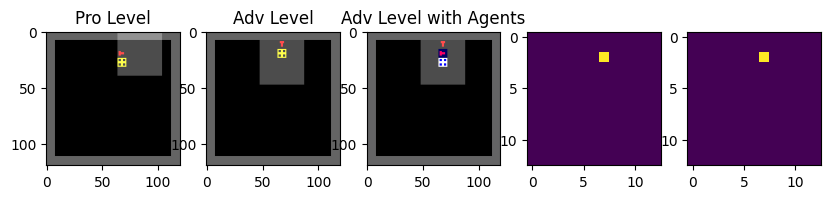

In [41]:
LEVEL_NUM = 4

pro_hstate, pro_obs, pro_env_state, pro_last_done, pro_total_steps, _ = pro_carry
adv_hstate, adv_obs, adv_env_state, adv_last_done, adv_total_steps, _ = adv_carry

pro_level_images = jax.vmap(env_renderer.render_state, (0, None))(pro_env_state.env_state, env_params)
adv_level_images = jax.vmap(adv_env_renderer.render_state, (0, None))(adv_env_state.level, adv_env_params)
adv_level_images_w_agents = jax.vmap(ani_adv_env_renderer.render_state, (0, None))(adv_env_state, adv_env_params)


fig, axes = plt.subplots(1, 5, figsize=(10, 5))
axes[0].imshow(pro_level_images[LEVEL_NUM])
axes[0].set_title("Pro Level")

axes[1].imshow(adv_level_images[LEVEL_NUM])
axes[1].set_title("Adv Level")

axes[2].imshow(adv_level_images_w_agents[LEVEL_NUM])
axes[2].set_title("Adv Level with Agents")

axes[3].imshow(pro_env_state.env_state.box_map[LEVEL_NUM])
axes[4].imshow(pro_env_state.env_state.box_map_reset[LEVEL_NUM])

In [22]:
pro_env_state.env_state.box_map_reset

Array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [ ]:
(rng, pro_carry, adv_carry, step_count, (pro_traj_idxs, adv_traj_idxs), pro_not_done), ((full_pro_traj, full_adv_traj), full_pro_locations, full_student_adv_idxs, full_student_adv_env_states) = jax.lax.scan(
    sample_step,
    (rng, pro_carry, adv_carry, step_count, (pro_traj_idxs, adv_traj_idxs), pro_not_done),
    None,
    length=max_student_episode_length+max_adv_episode_length,
)

def get_last_value(train_state, carry):
    hstate, last_obs, _, last_done, _, _ = carry
    x = jax.tree_map(lambda x: x[None, ...], (last_obs, last_done))
    _, _, last_value = train_state.apply_fn(train_state.params, x, hstate)
    return last_value

last_values = get_last_value(pro_train_state, pro_carry).squeeze(0), get_last_value(adv_train_state, adv_carry).squeeze(0)
last_pro_env_state = pro_carry[2]
last_pro_location = jnp.concatenate([last_pro_env_state.env_state.has_key[:, None], last_pro_env_state.env_state.agent_dir[:, None], last_pro_env_state.env_state.agent_pos], axis=-1)

(pro_traj, pro_locations) = jax.tree_map(lambda x: x[pro_traj_idxs, jnp.arange(num_pro_envs)], (full_pro_traj, full_pro_locations))

student_traj_idxs = pro_traj_idxs.reshape(-1, num_envs, num_pro_traj)
student_adv_idxs = full_student_adv_idxs[student_traj_idxs.min(axis=2), jnp.arange(num_envs)]
student_adv_env_states = jax.tree_map(lambda x : x[student_traj_idxs.min(axis=2), jnp.arange(num_envs)], full_student_adv_env_states)